In [1]:
import sys
print(sys.executable)

C:\Users\trida\Anaconda\envs\venv_mental_health\python.exe


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alitaqishah/global-mental-health-crisis-index-2026")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\trida\.cache\kagglehub\datasets\alitaqishah\global-mental-health-crisis-index-2026\versions\1


In [3]:
import os 
import pandas as pd

print("Các file trong thư mục:", os.listdir(path))

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if len(csv_files)>0:
    csv_file_path = os.path.join(path, csv_files[0])
    print(f"\nLoading data from: {csv_file_path}")

    df = pd.read_csv(csv_file_path)

    display(df.head())
else:
    print("Can't find any .csv file. Try again!!")

Các file trong thư mục: ['Global_Mental_Health_Crisis_Index_2026.csv']

Loading data from: C:\Users\trida\.cache\kagglehub\datasets\alitaqishah\global-mental-health-crisis-index-2026\versions\1\Global_Mental_Health_Crisis_Index_2026.csv


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [4]:
print(df['social_media_mental_health_risk'].value_counts())

social_media_mental_health_risk
Moderate (1.5-2.5h)    44
High (2.5-3.5h)        25
Low (<1.5h)            18
Very High (>3.5h)       5
Name: count, dtype: int64


In [5]:
unique_label = df['social_media_mental_health_risk'].unique()
risk_mapping = {label: i for i, label in enumerate(unique_label)}
print(risk_mapping)

{'Low (<1.5h)': 0, 'Moderate (1.5-2.5h)': 1, 'High (2.5-3.5h)': 2, 'Very High (>3.5h)': 3}


In [6]:
df['social_media_mh_risk_encoded']=df['social_media_mental_health_risk'].map(risk_mapping)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 30 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     object 
 1   iso3                                    92 non-null     object 
 2   region                                  92 non-null     object 
 3   income_group                            92 non-null     object 
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per100k                    92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_health                    92 non-null     float64
 9   mh_spend_usd_per_capita                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     int64  


In [8]:
df.describe()

,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,...,youth_mh_crisis_score,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,social_media_mh_risk_encoded
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.0,92.000000
mean,4.402174,5.632609,11.559783,7.182283,3.758696,38.951087,58.934783,2.209783,73.750000,22231.608696,...,7.410870,58.293478,7.340870,71.822826,0.146359,2.201087,32.958696,2.923913,2025.0,1.184783
std,0.754471,1.201657,9.825511,9.485814,2.960366,63.418593,27.884694,0.786711,24.262133,25685.337791,...,1.211434,13.637004,18.300855,94.858139,0.048522,0.377235,27.460854,1.008030,0.0,0.811041
min,2.900000,3.800000,3.200000,0.020000,0.600000,0.100000,17.000000,0.100000,8.000000,600.000000,...,5.100000,36.000000,0.050000,0.200000,0.058000,1.450000,3.100000,1.000000,2025.0,0.000000
25%,3.800000,4.800000,7.575000,0.500000,1.200000,0.725000,26.000000,1.600000,68.750000,3975.000000,...,6.300000,45.750000,0.857500,5.000000,0.106000,1.900000,9.025000,2.000000,2025.0,1.000000
50%,4.400000,5.200000,9.800000,3.150000,2.850000,8.000000,64.500000,2.100000,82.500000,10150.000000,...,7.500000,58.000000,2.225000,31.500000,0.144500,2.200000,23.700000,3.000000,2025.0,1.000000
75%,4.900000,6.100000,12.825000,12.450000,5.650000,49.750000,84.500000,2.800000,92.250000,33975.000000,...,8.400000,69.000000,5.977500,124.500000,0.179000,2.450000,55.875000,4.000000,2025.0,2.000000
max,6.300000,9.300000,87.500000,54.900000,11.300000,320.000000,97.000000,4.800000,99.000000,106900.000000,...,9.500000,87.000000,121.430000,549.000000,0.244000,3.150000,100.000000,4.000000,2025.0,3.000000


In [9]:
df.isnull().sum()

country                                   0
iso3                                      0
region                                    0
income_group                              0
depression_pct                            0
anxiety_pct                               0
suicide_rate_per100k                      0
psychiatrists_per100k                     0
mh_budget_pct_health                      0
mh_spend_usd_per_capita                   0
treatment_gap_pct                         0
social_media_hours_daily                  0
internet_penetration_pct                  0
gdp_per_capita_usd                        0
population_millions                       0
covid_mh_increase_pct                     0
youth_mh_crisis_score                     0
mh_policy_exists                          0
mh_law_exists                             0
mh_crisis_index                           0
total_affected_millions                   0
psychiatrists_per_million                 0
mh_investment_gap               

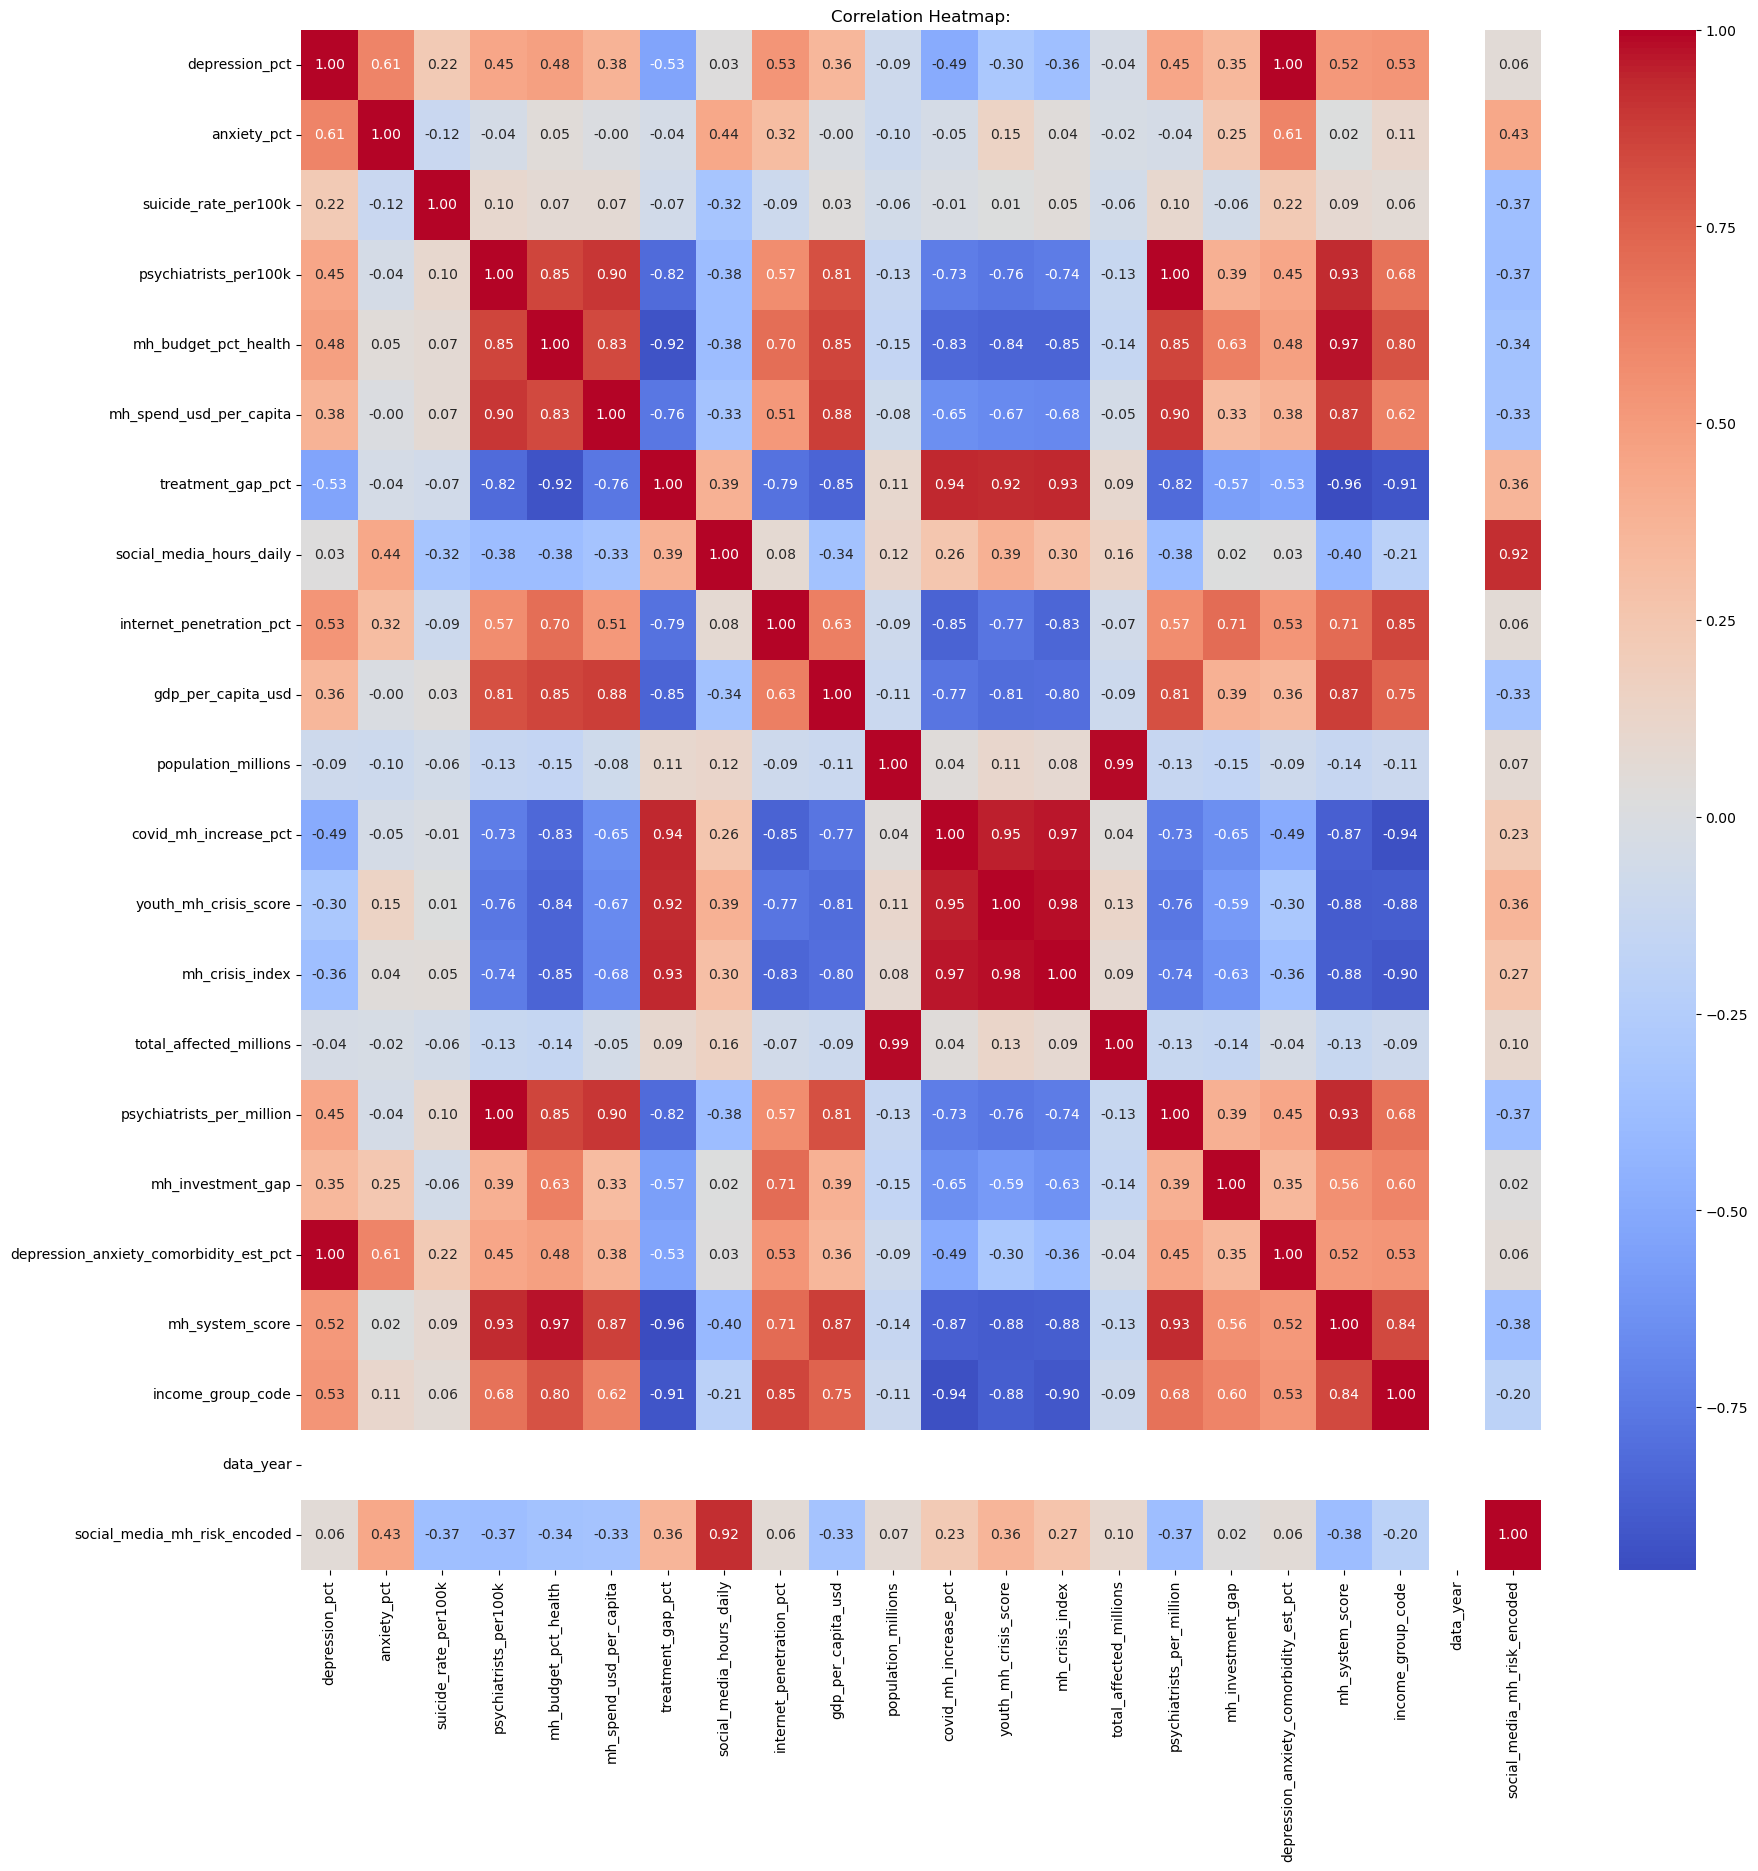

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,20))

numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap:")
plt.show()

In [11]:
#sns.pairplot(df)
#plt.show()

<Axes: xlabel='mh_crisis_index', ylabel='Count'>

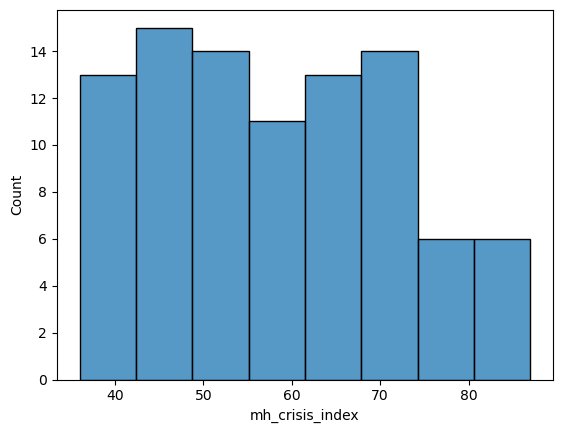

In [12]:
sns.histplot(df['mh_crisis_index'])

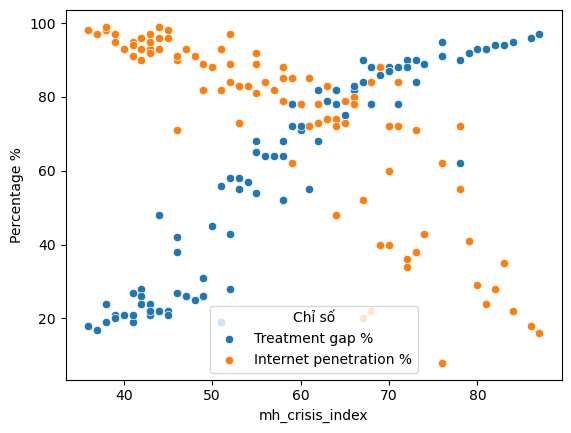

In [13]:
sns.scatterplot(x='mh_crisis_index', y = 'treatment_gap_pct', data=df, label = 'Treatment gap %')
sns.scatterplot(x='mh_crisis_index', y = 'internet_penetration_pct', data=df, label='Internet penetration %')

plt.ylabel('Percentage %')
plt.legend(title = 'Chỉ số')
plt.show()

<Axes: xlabel='mh_crisis_index', ylabel='income_group_code'>

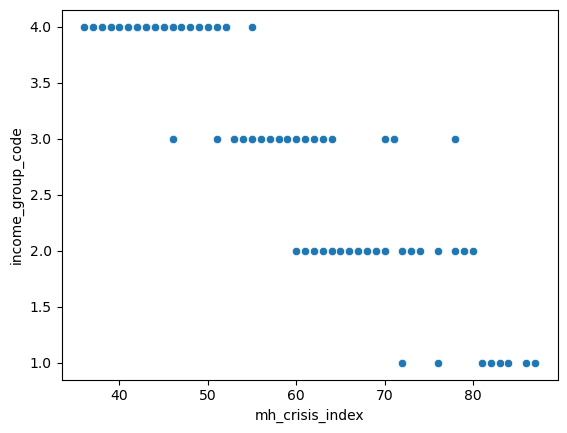

In [14]:
sns.scatterplot(x='mh_crisis_index', y = 'income_group_code', data=df)

<Axes: xlabel='depression_pct', ylabel='anxiety_pct'>

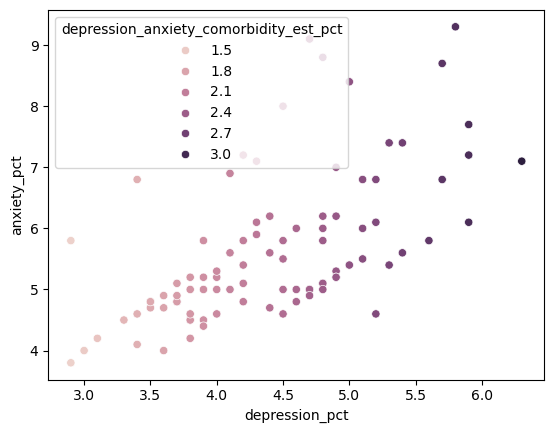

In [15]:
sns.scatterplot(x='depression_pct', y='anxiety_pct', hue = 'depression_anxiety_comorbidity_est_pct', data=df)

### Overall

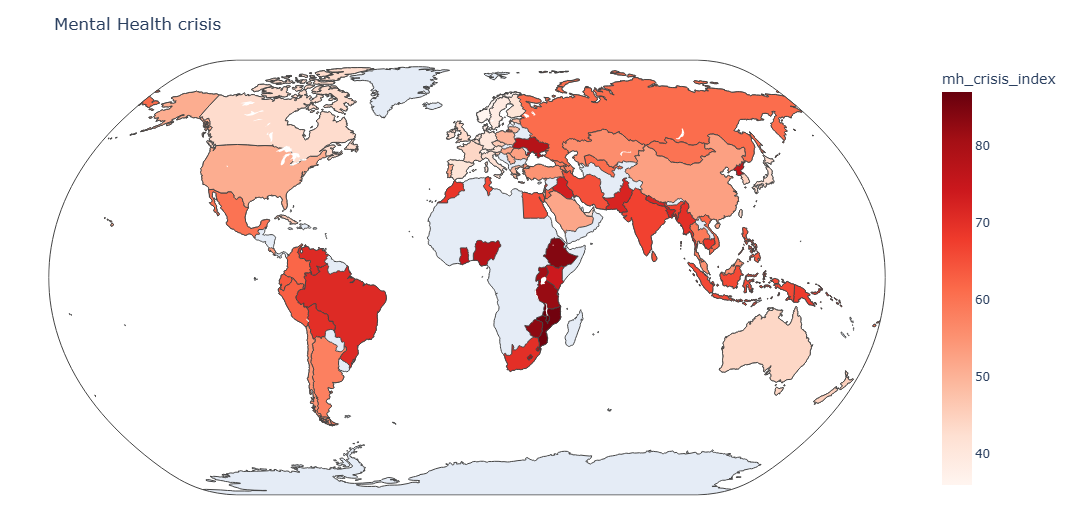

In [16]:
import plotly.express as px

fig_map = px.choropleth(df, 
                        locations = "iso3",
                        locationmode = 'ISO-3',
                        color = "mh_crisis_index",
                        hover_name = "country",
                        title = "Mental Health crisis",
                        projection = 'natural earth',
                        color_continuous_scale="Reds"
                       )
fig_map.update_layout(
    autosize=True,
    width=1100, 
    height=500,
    margin=dict(l=20, r=20, t=60, b=20),
)
fig_map.show()

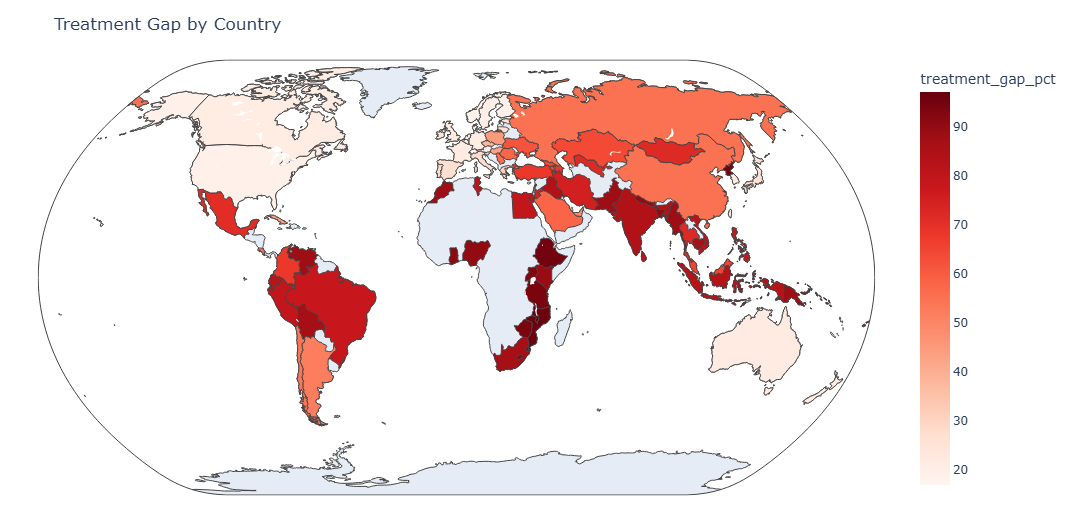

In [17]:


fig_treatment = px.choropleth(df, 
                        locations = "iso3",
                        locationmode = 'ISO-3',
                        color = "treatment_gap_pct",
                        hover_name = "country",
                        title = "Treatment Gap by Country",
                        projection = 'natural earth',
                        color_continuous_scale="Reds"
                       )

fig_treatment.update_layout(
    autosize=True,
    width=1100, 
    height=500,
    margin=dict(l=20, r=20, t=60, b=20),
)
fig_treatment.show()

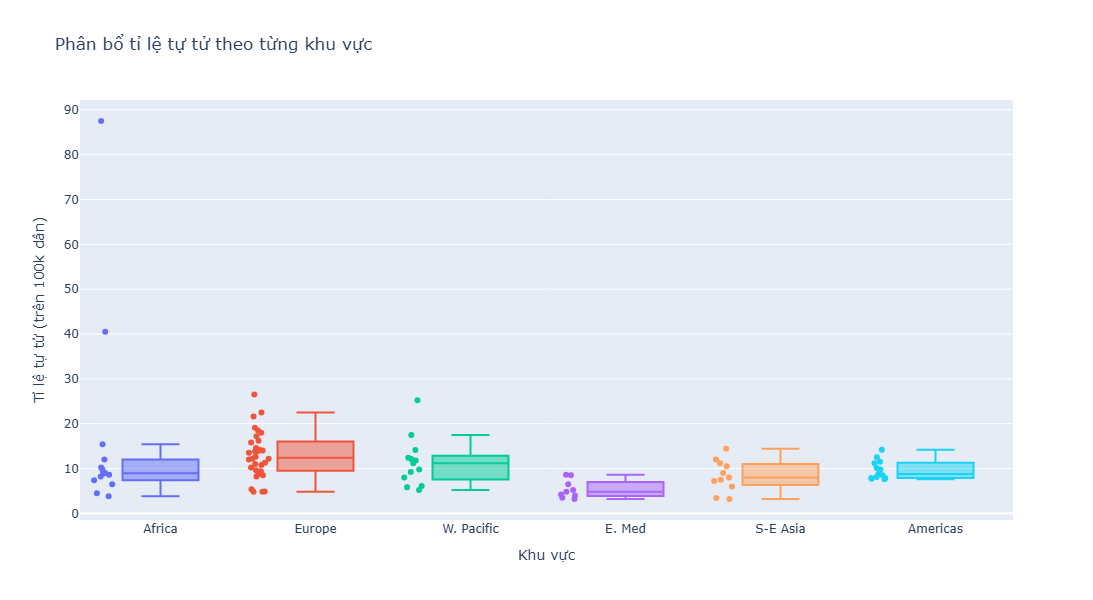

In [18]:
fig_box = px.box(df, 
                 x="region", 
                 y="suicide_rate_per100k", 
                 color="region",
                 points="all", # Hiển thị các quốc gia thành các chấm nhỏ bên cạnh hộp
                 hover_name="country",
                 title="Phân bổ tỉ lệ tự tử theo từng khu vực")

# Chỉnh cho đẹp hơn
fig_box.update_layout(
    xaxis_title="Khu vực",
    yaxis_title="Tỉ lệ tự tử (trên 100k dân)",
    showlegend=False,
    height=600
)

fig_box.show()

### 1. Governance & System

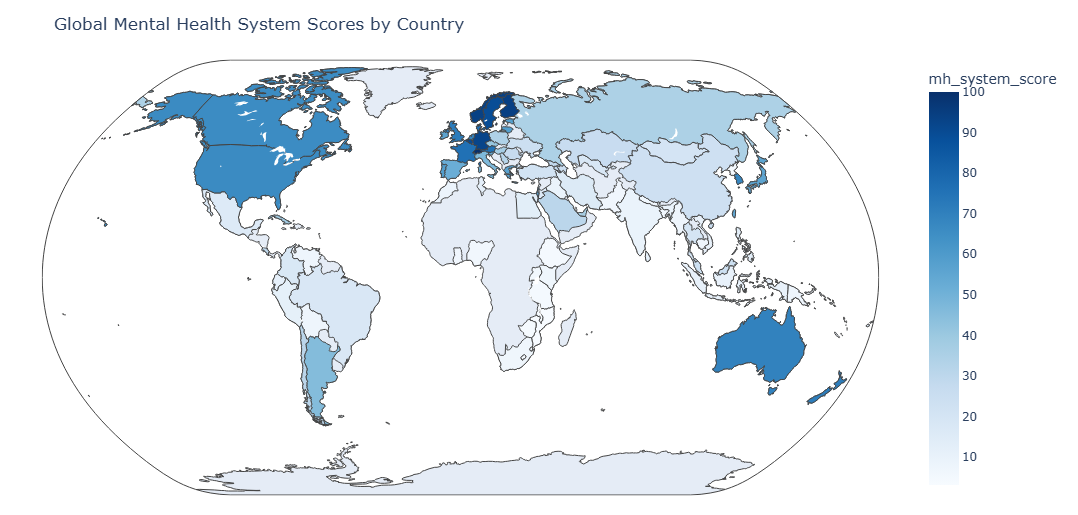

In [19]:
import plotly.express as px

fig1_1 = px.choropleth(df, 
                        locations = "iso3",
                        locationmode = 'ISO-3',
                        color = "mh_system_score",
                        hover_name = "country",
                        title = "Global Mental Health System Scores by Country",
                        projection = 'natural earth',
                        color_continuous_scale="Blues"
                       )
fig1_1.update_layout(
    autosize=True,
    width=1100, 
    height=500,
    margin=dict(l=20, r=20, t=60, b=20),
)
fig1_1.show()

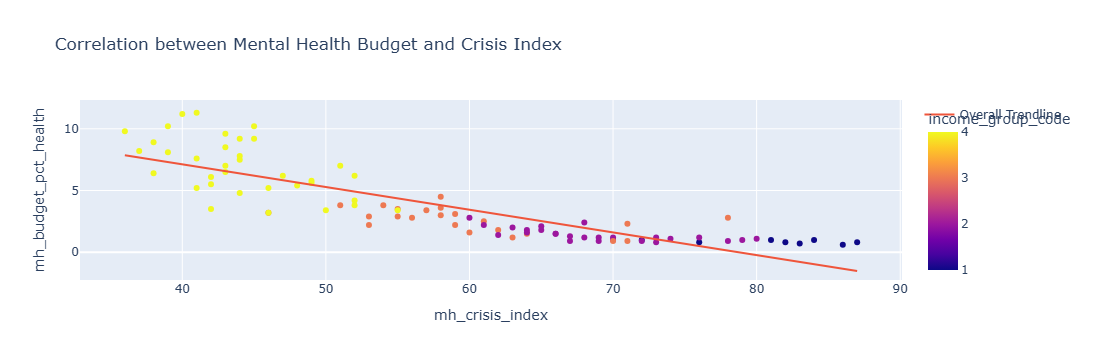

In [20]:
fig1_2 = px.scatter(df,
                    y= 'mh_budget_pct_health',
                    x='mh_crisis_index',
                    color='income_group_code',
                    hover_name='country',
                    trendline='ols',
                    trendline_scope='overall',
                    title='Correlation between Mental Health Budget and Crisis Index',
                   )
fig1_2.show()

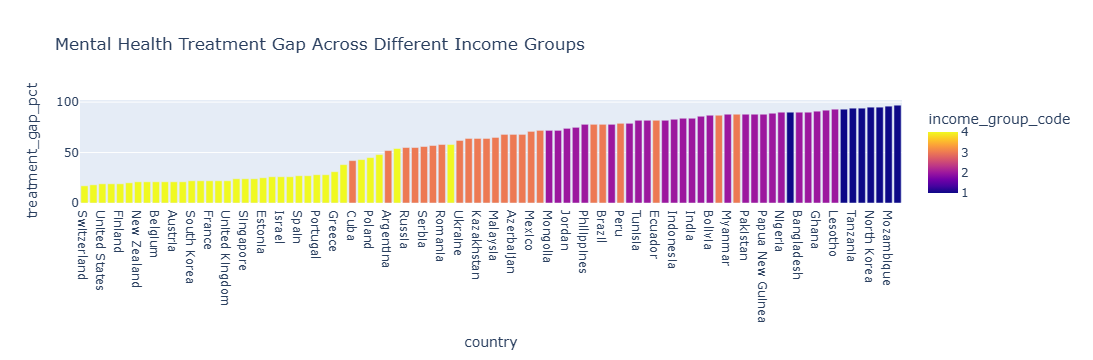

In [21]:
fig1_3 = px.bar(df.sort_values('treatment_gap_pct'),
                x='country',
                y='treatment_gap_pct',
                color='income_group_code',
                title='Mental Health Treatment Gap Across Different Income Groups'
               )
fig1_3.show()

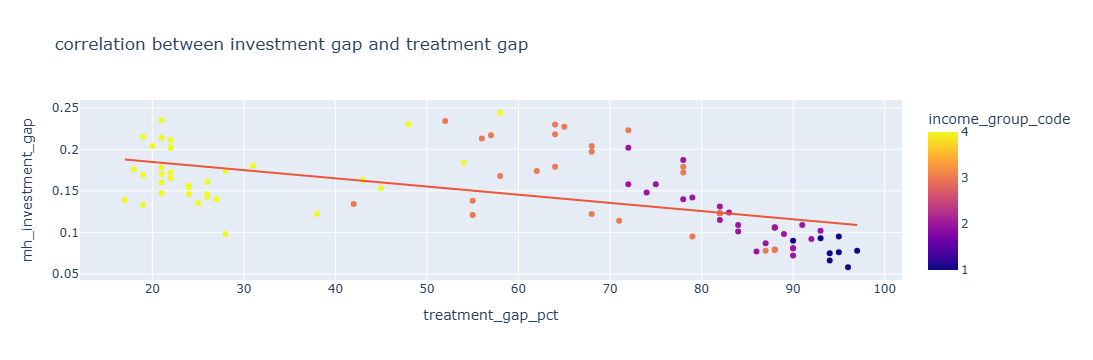

In [22]:
fig3_5=px.scatter(df,
                  x='treatment_gap_pct',
                  y='mh_investment_gap',
                  color='income_group_code',
                  hover_name='country',
                  trendline='ols',
                  title='correlation between investment gap and treatment gap')
fig3_5.show()

### 2. Socio-Economics & Human Resources

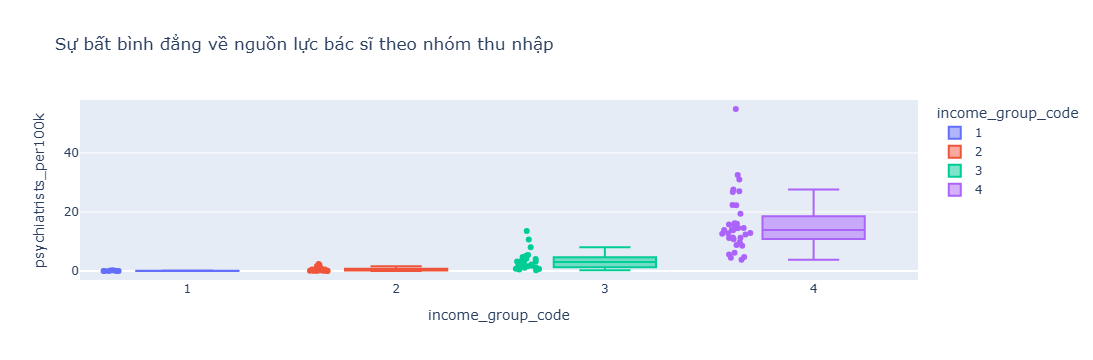

In [23]:
fig2_1 = px.box(df,
                x='income_group_code',
                y='psychiatrists_per100k',
                color='income_group_code',
                points='all',
                hover_name='country',
                title='Sự bất bình đẳng về nguồn lực bác sĩ theo nhóm thu nhập')

fig2_1.show()

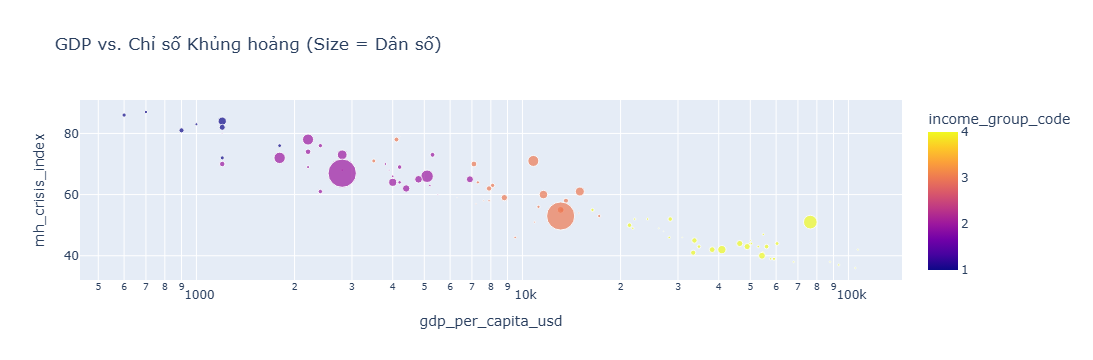

In [24]:
#GDP vs Khủng hoảng
fig2_2 = px.scatter(df,
                    x='gdp_per_capita_usd',
                    y='mh_crisis_index',
                    size='population_millions',
                    color='income_group_code',
                    hover_name='country',
                    log_x=True,# Dùng thang log cho GDP để dễ nhìn hơn
                    title='GDP vs. Chỉ số Khủng hoảng (Size = Dân số)')

fig2_2.show()


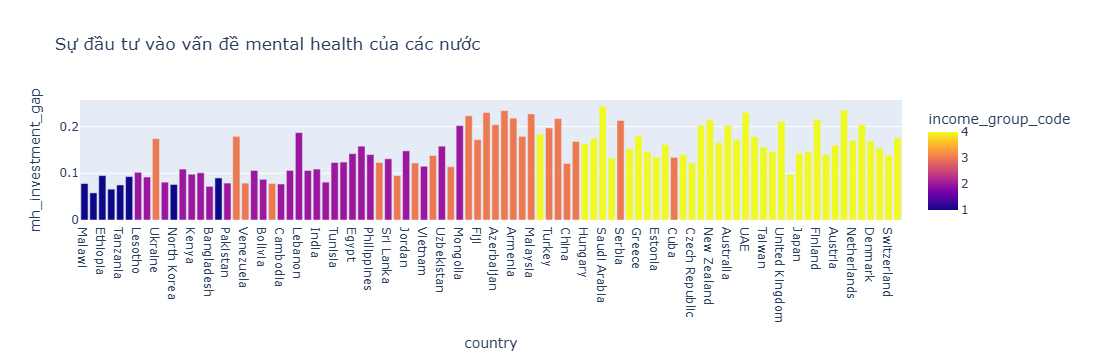

In [25]:
# 3. Khoảng cách đầu tư
fig2_3=px.bar(df,
              y='mh_investment_gap',
              x='country',
              color='income_group_code',
              title='Sự đầu tư vào vấn đề mental health của các nước')

fig2_3.show()

### 3. Digital Life & Well-being

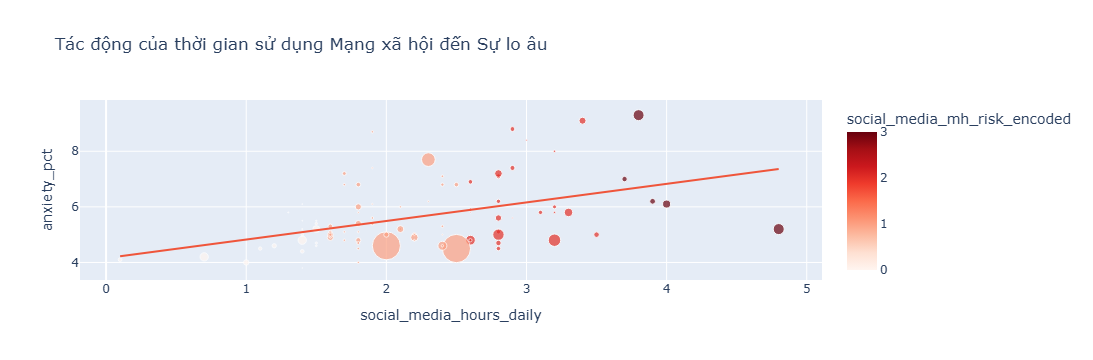

In [26]:
# 1. Mạng xã hội và Trầm cảm/Lo âu (Tương quan 0.92), social_media_mh_risk_encoded
fig3_1=px.scatter(df,
                  x='social_media_hours_daily',
                  y='anxiety_pct',
                  color='social_media_mh_risk_encoded',
                  size='population_millions',
                  trendline='ols',
                  hover_name='country',
                  color_continuous_scale="Reds",
                  title='Tác động của thời gian sử dụng Mạng xã hội đến Sự lo âu')

fig3_1.show()

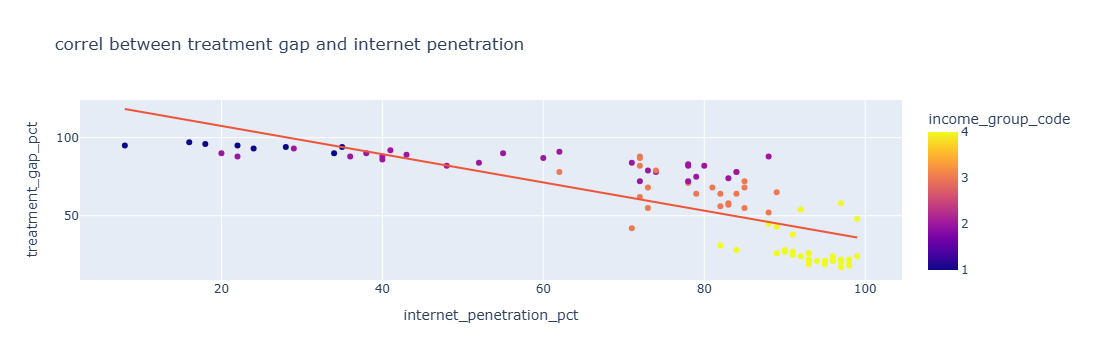

In [27]:
# 2. More internet, fewer treatment gaps
fig3_2=px.scatter(df,
                  x='internet_penetration_pct',
                  y='treatment_gap_pct',
                  color='income_group_code',
                  hover_name='country',
                  trendline='ols',
                  title='correl between treatment gap and internet penetration')
fig3_2.show()

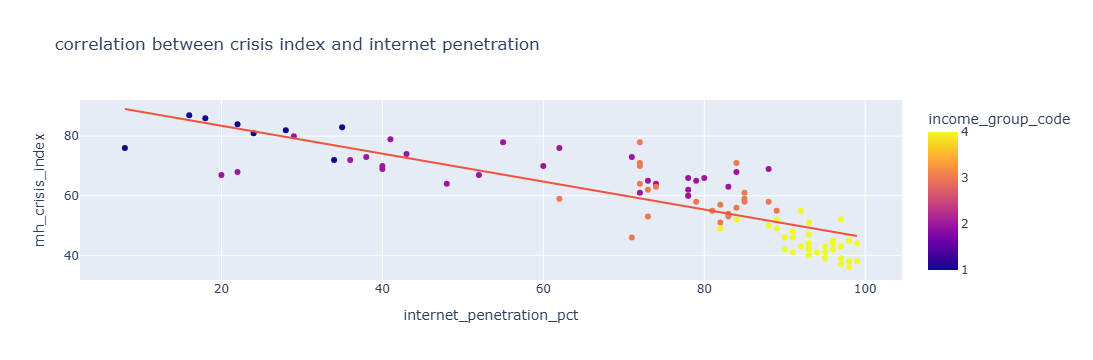

In [28]:
# 2. More internet, more budget for mh
fig3_3=px.scatter(df,
                  x='internet_penetration_pct',
                  y='mh_crisis_index',
                  color='income_group_code',
                  hover_name='country',
                  trendline='ols',
                  title='correlation between crisis index and internet penetration')
fig3_3.show()

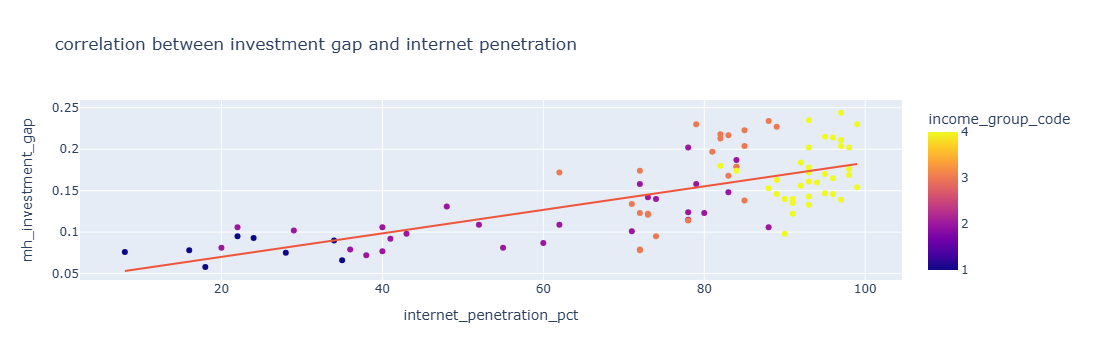

In [29]:
fig3_4=px.scatter(df,
                  x='internet_penetration_pct',
                  y='mh_investment_gap',
                  color='income_group_code',
                  hover_name='country',
                  trendline='ols',
                  title='correlation between investment gap and internet penetration')
fig3_4.show()